# Exploración Inicial de los Datos (Exploratory Data Analysis - EDA)



In [ ]:
# imports

import mysql.connector
import pandas as pd
import json


# graficos
import matplotlib.pyplot as plt 

In [25]:
# SQL connector

with open("config.json") as f:
    config = json.load(f)

# Conectar
conexion = mysql.connector.connect(**config)

print("Conexión exitosa")

Conexión exitosa


In [26]:
# validar que funciona: SHOW TABLES

tablas = pd.read_sql("SHOW TABLES;", conexion)
nombre_tablas = tablas.iloc[:, 0].tolist()

print(tablas)


  Tables_in_Equip_30
0     BANK_marketing


_______
COPIAS CSV

In [ ]:
# Exportar cada tabla como CSV
for tabla in nombre_tablas:
    df = pd.read_sql(f"SELECT * FROM {tabla};", conexion)
    df.to_csv(f"../Data/{tabla}_raw.csv", index=False) # COPIA RAW
    df.to_csv(f"../Data/{tabla}_eda.csv", index=False) # COPIA EDA

print("\nExportación completa")


Exportación completa


___
# CERRAR CONEXIÓN

In [21]:
# CERRAR CONEXIÓN

conexion.close()
print("Conexión cerrada")

Conexión cerrada


____
# CREAR DF

In [ ]:
# Crear dataframe + read csv
df_marketing = pd.read_csv("../Data/BANK_marketing_eda.csv")

print(f"Registros: {len(df_marketing)}")
print(f"Columnas: {df_marketing.shape[1]}")
print("\nTipos de datos:")
print(df_marketing.dtypes)


Registros: 10642
Columnas: 18

Tipos de datos:
id             int64
age          float64
job           object
marital       object
education     object
default       object
balance        int64
housing       object
loan          object
contact       object
day            int64
month         object
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome      object
deposit       object
dtype: object


In [32]:
display(df_marketing)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10637,10638,33.0,technician,married,secondary,no,218,yes,yes,telephone,2,mar,169,4,-1,0,unknown,no
10638,10639,42.0,management,single,tertiary,no,1146,yes,no,unknown,15,may,98,2,-1,0,unknown,no
10639,10640,31.0,unemployed,single,unknown,no,167,no,no,cellular,20,nov,316,1,-1,0,unknown,no
10640,10641,30.0,blue-collar,single,secondary,yes,447,no,no,cellular,19,nov,426,2,189,6,failure,no


____
# RESUMEN ESTADÍSTICO

.describe // .value_counts // .info 

In [33]:
# Resumen estadístico ### INFO
display(df_marketing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10642 entries, 0 to 10641
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         10642 non-null  int64  
 1   age        10633 non-null  float64
 2   job        10642 non-null  object 
 3   marital    10637 non-null  object 
 4   education  10635 non-null  object 
 5   default    10642 non-null  object 
 6   balance    10642 non-null  int64  
 7   housing    10642 non-null  object 
 8   loan       10642 non-null  object 
 9   contact    10642 non-null  object 
 10  day        10642 non-null  int64  
 11  month      10642 non-null  object 
 12  duration   10642 non-null  int64  
 13  campaign   10642 non-null  int64  
 14  pdays      10642 non-null  int64  
 15  previous   10642 non-null  int64  
 16  poutcome   10642 non-null  object 
 17  deposit    10642 non-null  object 
dtypes: float64(1), int64(7), object(10)
memory usage: 1.5+ MB


None

In [34]:
#  Valores nulos por columna
nulos_marketing = df_marketing.isnull().sum()
nulos_marketing = nulos_marketing[nulos_marketing > 0]


print(nulos_marketing if not nulos_marketing.empty else "Sin valores nulos.")

age          9
marital      5
education    7
dtype: int64


In [35]:
# Detección de 'unknown' (cualquier variación)
print("\nVALORES 'UNKNOWN':")
cols_categoricas = df_marketing.select_dtypes(include='object').columns
for col in cols_categoricas:
    count = df_marketing[col].str.lower().str.strip().eq('unknown').sum() #contar cantidad de unknown
    if count > 0:
        print(f"  {col}: {count}")


VALORES 'UNKNOWN':
  job: 68
  education: 473
  contact: 2196
  poutcome: 7885


In [236]:
# Resumen estadístico ### VALUE COUNTS
display(df_marketing.value_counts())

id     age   job            marital  education  default  balance  housing  loan  contact    day  month  duration  campaign  pdays  previous  poutcome  deposit
1      59.0  admin.         married  secondary  no        2343    yes      no    unknown    5    may    1042      1         -1     0         unknown   yes        1
7089   80.0  retired        married  secondary  no        173     no       no    cellular   2    aug    87        3         -1     0         unknown   no         1
7091   36.0  services       married  secondary  no        335     yes      no    unknown    9    may    339       2         -1     0         unknown   no         1
7092   31.0  blue-collar    single   unknown    yes       17      yes      no    cellular   6    may    72        1         -1     0         unknown   no         1
7093   33.0  technician     married  secondary  no       -74      yes      no    cellular   25   jul    198       4         -1     0         unknown   no         1
                     

In [237]:
# Resumen estadístico ### DESCRIBE
display(df_marketing.describe())

,id,age,balance,day,duration,campaign,pdays,previous
count,10642.000000,10633.000000,10642.000000,10642.000000,10642.000000,10642.000000,10642.000000,10642.000000
mean,5321.500000,41.252610,1536.614828,15.645461,378.693197,2.496147,52.073670,0.851344
std,3072.225117,12.003015,3223.419300,8.432874,351.180910,2.694660,109.208889,2.321755
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,2661.250000,32.000000,127.000000,8.000000,141.000000,1.000000,-1.000000,0.000000
50%,5321.500000,39.000000,558.000000,15.000000,260.000000,2.000000,-1.000000,0.000000
75%,7981.750000,49.000000,1728.750000,22.000000,510.000000,3.000000,57.750000,1.000000
max,10642.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [238]:
# Min/Max de variables numéricas (primer vistazo de valores atípicos)

display(df_marketing.select_dtypes(include='number').agg(['min', 'max'])) #seleccion por datatype NUMERO

,id,age,balance,day,duration,campaign,pdays,previous
min,1,18.0,-6847,1,2,1,-1,0
max,10642,95.0,81204,31,3881,63,854,58


______
# VISUALIZACIONES INICIALES

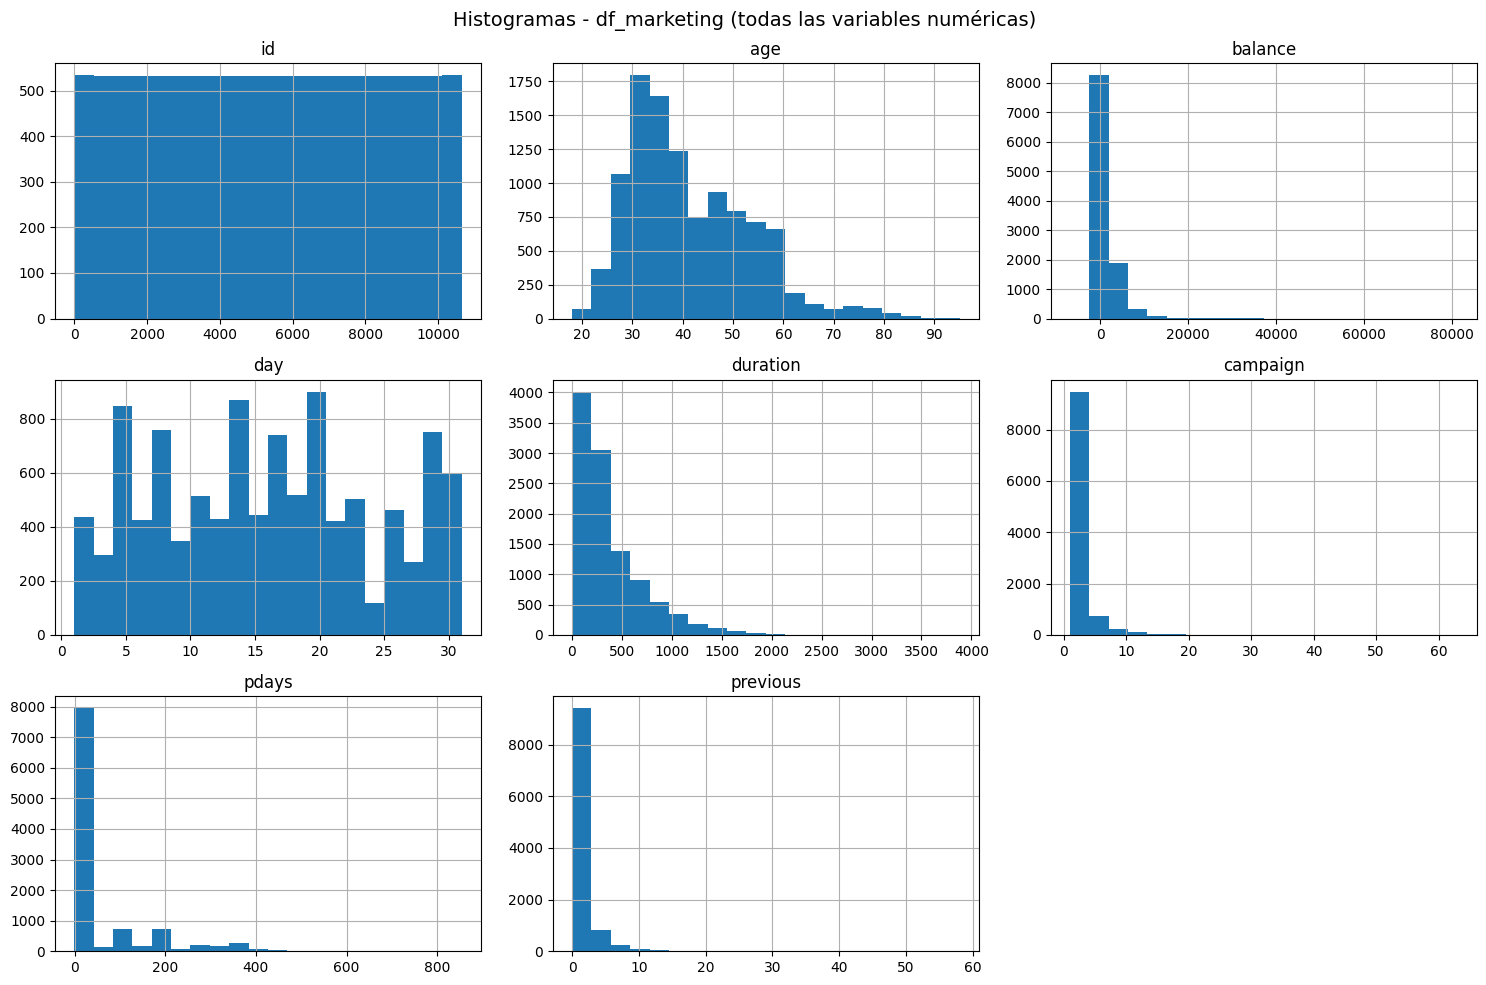

In [239]:
# Variables numéricas
cols_numericas = df_marketing.select_dtypes(include='number').columns #seleccion por datatype NUMERO

# 1. Todas las variables numéricas en un solo bloque
df_marketing[cols_numericas].hist(bins=20, figsize=(15, 10))
plt.suptitle("Histogramas - df_marketing (todas las variables numéricas)", fontsize=14)
plt.tight_layout()
plt.show()

In [36]:
# Value counts por columna categórica
cols_categoricas = df_marketing.select_dtypes(include='object').columns

for col in cols_categoricas:
    print(f"\n{col}:")
    print(df_marketing[col].value_counts())


job:
management       2447
blue-collar      1830
technician       1737
admin.           1279
services          881
retired           755
self-employed     388
student           354
unemployed        338
entrepreneur      308
housemaid         257
unknown            68
Name: job, dtype: int64

marital:
married     6030
single      3374
divorced    1233
Name: marital, dtype: int64

education:
secondary    5216
tertiary     3527
primary      1419
unknown       473
Name: education, dtype: int64

default:
no     10487
yes      155
Name: default, dtype: int64

housing:
no     5660
yes    4982
Name: housing, dtype: int64

loan:
no     9270
yes    1372
Name: loan, dtype: int64

contact:
cellular     7707
unknown      2196
telephone     739
Name: contact, dtype: int64

month:
may    2646
aug    1450
jul    1429
jun    1174
nov     898
apr     888
feb     746
oct     387
jan     327
sep     314
mar     274
dec     109
Name: month, dtype: int64

poutcome:
unknown    7885
failure    1180
success 

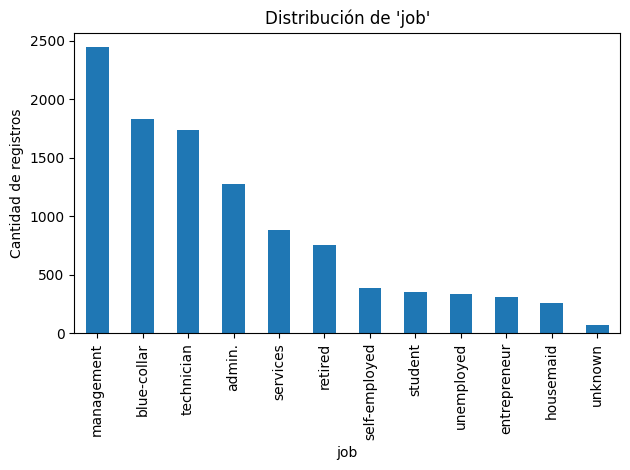

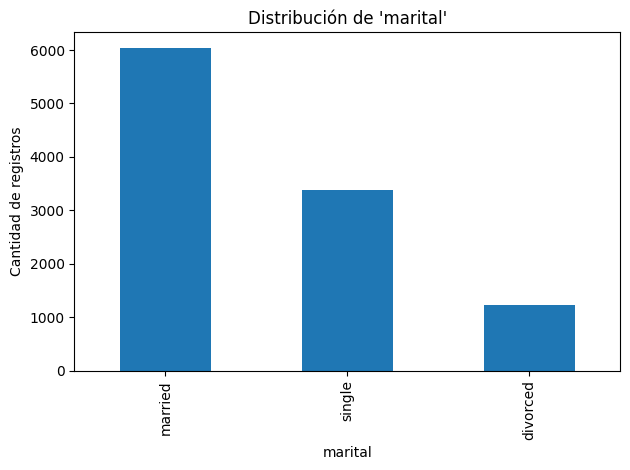

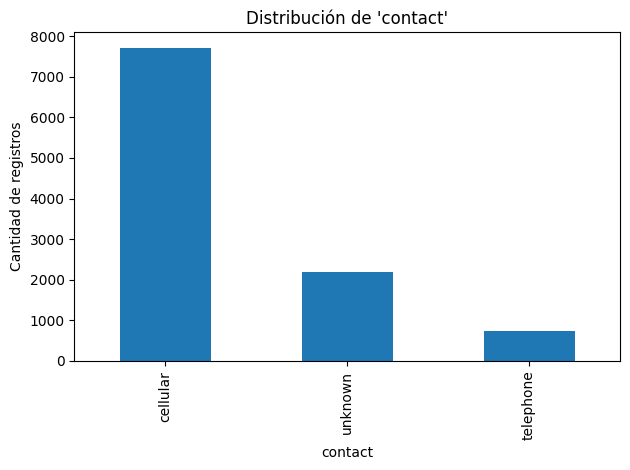

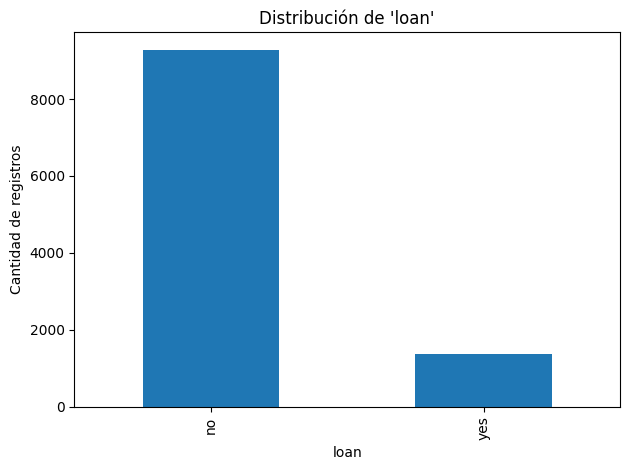

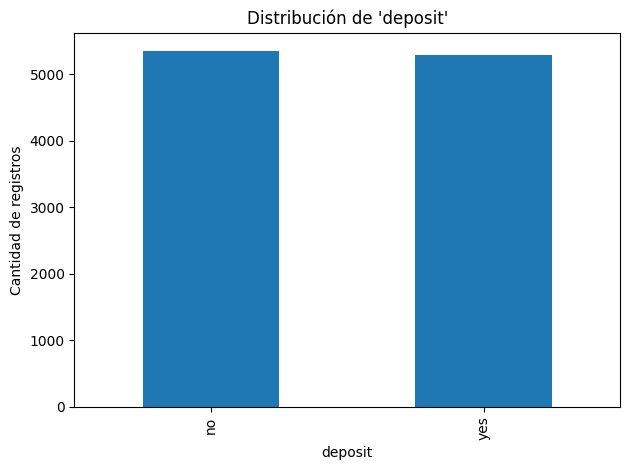

In [240]:
# Distribución de variables categóricas

categoricas = ['job', 'marital', 'contact', 'loan', 'deposit']

for col in categoricas:
    df_marketing[col].value_counts().plot.bar()
    plt.title(f"Distribución de '{col}'")
    plt.xlabel(col)
    plt.ylabel("Cantidad de registros")
    plt.tight_layout()
    plt.show()

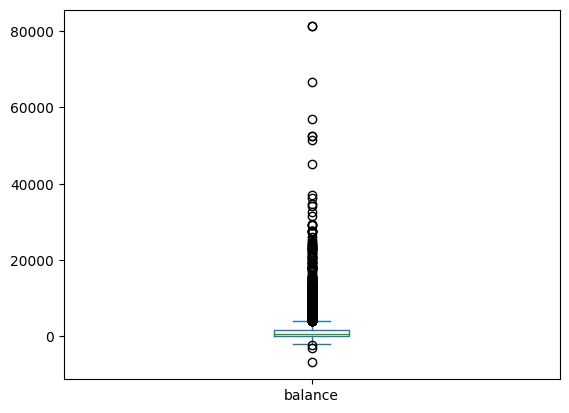

In [241]:
# balance ## BOX PLOT

df_marketing['balance'].plot.box();

Aquí con BALANCE hay algo raro
____
